In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot

import os, sys
sys.path.append(os.path.split(os.getcwd())[0]+'/src/')

# import magnus
import magnus.magnus as magnus
# import magnus.oscprob.oscprob as oscprob
# import magnus.oscprob.oscprobstd as oscprobstd
# import magnus.hamiltonians.hamiltonians2nu as hamiltonians2nu
# import magnus.hamiltonians.hamiltonians3nu as hamiltonians3nu
# import magnus.matter as matter
# import magnus.globaldefs as gd

While the main purpose of Mag$\nu$s is to compute neutrino oscillation probabilities, at its core, it is an efficient implementation of the Magnus expansion of the matrix exponential whose computation is required to compute the time-evolution operator for any given Hamiltonian, including time-dependent (or position-dependent) ones.  Therefore, we can use Mag$\nu$s to compute the Magnus expansion of the matrix exponential
\begin{equation}
 U = \exp\left( \int_{t_i}^{t_f} A(t) dt \right)
\end{equation}
where $A$ is an arbitary $N \times N$ square matrix.  The Magnus expansion of the exponential is
\begin{equation}
 U = \exp\left( \Omega(t_i, t_f) \right) \;,
\end{equation}
where $\Omega$ is the series expansion
\begin{equation}
 \Omega(t_i, t_f) = \sum_{k=1}^{\infty} \Omega_k(t_i, t_f) \;,
\end{equation}
where the terms $\Omega_k$ of the expansion are computed recursively in terms of lower-order terms (see Wikipedia entry).  Mag$\nu$s can return the terms $\Omega_k$ and also the matrix exponential, $U$.  The present version of the code implements calculation up to $k = 6$ term.

First, define a sample $3 \times 3$ complex matrix (unlike the Hamiltonian in the case of neutrino oscillations, it does not have to be Hermitian).

In [7]:
def A3(t):
    return np.array([[1+1j*t, 2*t**2, 3j*t], [0, 4-1j*t, 5+3j*t], [-3j*np.sqrt(t), -2j*t, 1]], dtype=np.complex128)

t_i, t_f = 0, 1 # Initial and final times of the matrix integral

The terms $\Omega_k$ of the expansion have the same dimensions as the input matrix $A_3$ (in this case, $3 \times 3$).  By default, the function `compute_magnus_terms` returns only $\Omega_1$ and $\Omega_2$, and the matrix integral is performed using trapezoidal integration on a grid of 50 points between $t_i$ and $t_f$, evenly spaced in $\log_{10}$ scale.

In [13]:
Omega_1, Omega_2 = magnus.compute_magnus_terms(A3, t_i, t_f) # Each Omega_k returned is a np.ndarray object
print(Omega_1) # The first-order term is just what we would compute were A3 time-independent
print(Omega_2) # The second-order term is the first correction to that

[[1.       +0.5j        0.6668055+0.j         0.       +1.5j       ]
 [0.       +0.j         4.       -0.5j        5.       +1.5j       ]
 [0.       -1.99823381j 0.       -1.j         1.       +0.j        ]]
[[ 2.13039123e-01+0.j          5.00104123e-01-0.06666666j
   8.33506872e-01+0.09999998j]
 [ 2.13039123e-01+1.00439272j -6.34413157e-17+0.83350687j
  -7.27309369e-16-1.16690962j]
 [-7.10130410e-02+0.j          0.00000000e+00-0.27842912j
  -2.13039123e-01-0.83350687j]]


Now compute terms up to $k = 6$, use a finer grid of 100 points to integrate, and switch from trapezoidal integration to integration via Simpson's rule.

In [18]:
Omega = magnus.compute_magnus_terms(A3, t_i, t_f, n_tpts=100, order=6, integration_method='simpson')
for k, Omega_k in enumerate(Omega):
    print(r'Omega_'+str(k+1)+' = ')
    print(Omega_k)

Omega_1 = 
[[1.        +0.5j        0.66666667+0.j         0.        +1.5j       ]
 [0.        +0.j         4.        -0.5j        5.        +1.5j       ]
 [0.        -1.99975275j 0.        -1.j         1.        +0.j        ]]
Omega_2 = 
[[ 2.14100232e-01+0.j          4.99999998e-01-0.06666667j
   8.33333330e-01+0.10000001j]
 [ 2.14100232e-01+1.00062475j  2.39239978e-17+0.83333333j
   1.27245763e-15-1.16666667j]
 [-7.13667440e-02+0.j          0.00000000e+00-0.27786019j
  -2.14100232e-01-0.83333333j]]
Omega_3 = 
[[ 0.02267765+0.14863816j  0.09128054+0.15555558j  0.20476192-0.21527521j]
 [ 0.25417758+0.04744315j  0.15874086-0.18195777j  0.40626653-0.04860856j]
 [ 0.22243158-0.04200305j  0.19580983-0.00107192j -0.1814185 +0.03331962j]]
Omega_4 = 
[[-0.07089118+0.02346725j -0.06016516+0.17680411j -0.19915226+0.27026506j]
 [-0.87357072-0.09227914j -0.35792706+0.00278848j  0.19770968+0.51034424j]
 [-0.10728678+0.08267535j  0.03275133-0.0611868j   0.42881824-0.02625573j]]
Omega_5 = 
[[-0.225

To compute the matrix exponential $\exp(\Omega)$, we do not need to compute the Magnus terms separately first.  We can directly call the `magnus_expansion` function, which does it internally.

In [20]:
exp_Omega = magnus.magnus_expansion(A3, t_i, t_f)
print(exp_Omega)

[[  5.32411224-13.9774973j   28.00484149-31.29625983j
   45.7821808 -28.44671839j]
 [-11.65247639-34.25159665j  27.93736985-74.13198684j
   67.6303491 -88.4834311j ]
 [-15.90825353 -4.02875051j -35.08446759-27.08530523j
  -32.97571418-46.42222427j]]


And, like before, we can change the order of the expansion, the number of points used in the integration grid, and the integration method.

In [22]:
exp_Omega = magnus.magnus_expansion(A3, t_i, t_f, n_tpts=100, order=6, integration_method='simpson')
print(exp_Omega)

[[  8.68670827 -21.82438345j  42.15944503 -33.88166442j
   67.40807147 -19.01354488j]
 [-24.33910083 -59.38768063j  37.12830675-128.96839132j
  112.1350887 -141.47193713j]
 [-25.27617843  -7.7598675j  -39.97753621 -44.84450399j
  -24.66584243 -73.82736473j]]


Naturally, the more terms in the Magnus expansion and the finer the integration grid, the more accurate the returned matrix exponential is.  To illustrate this, let's plot the value of the real part of the $U_{11}$ component (i.e., of `exp_Omega[0][0]`) for different choices. 

In [84]:
# Generate the data
n_tpts_min, n_tpts_max = 2, 10
order_max = 6
elem_sel_i, elem_sel_j = 0, 1 # Select the [0][0] element of the returned matrix exponential
exp_Omega_elem_sel = [[magnus.magnus_expansion(A3, t_i, t_f, n_tpts=n, order=o+1, 
                                              integration_method='trapezoid')[elem_sel_i][elem_sel_j].real 
                      for n in range(n_tpts_min, n_tpts_max+1)] for o in range(order_max)]
exp_Omega_elem_sel = np.array(exp_Omega_elem_sel)

Text(0, 0.5, '$\\epsilon_{\\rm rel}$ vs.~$k=6$')

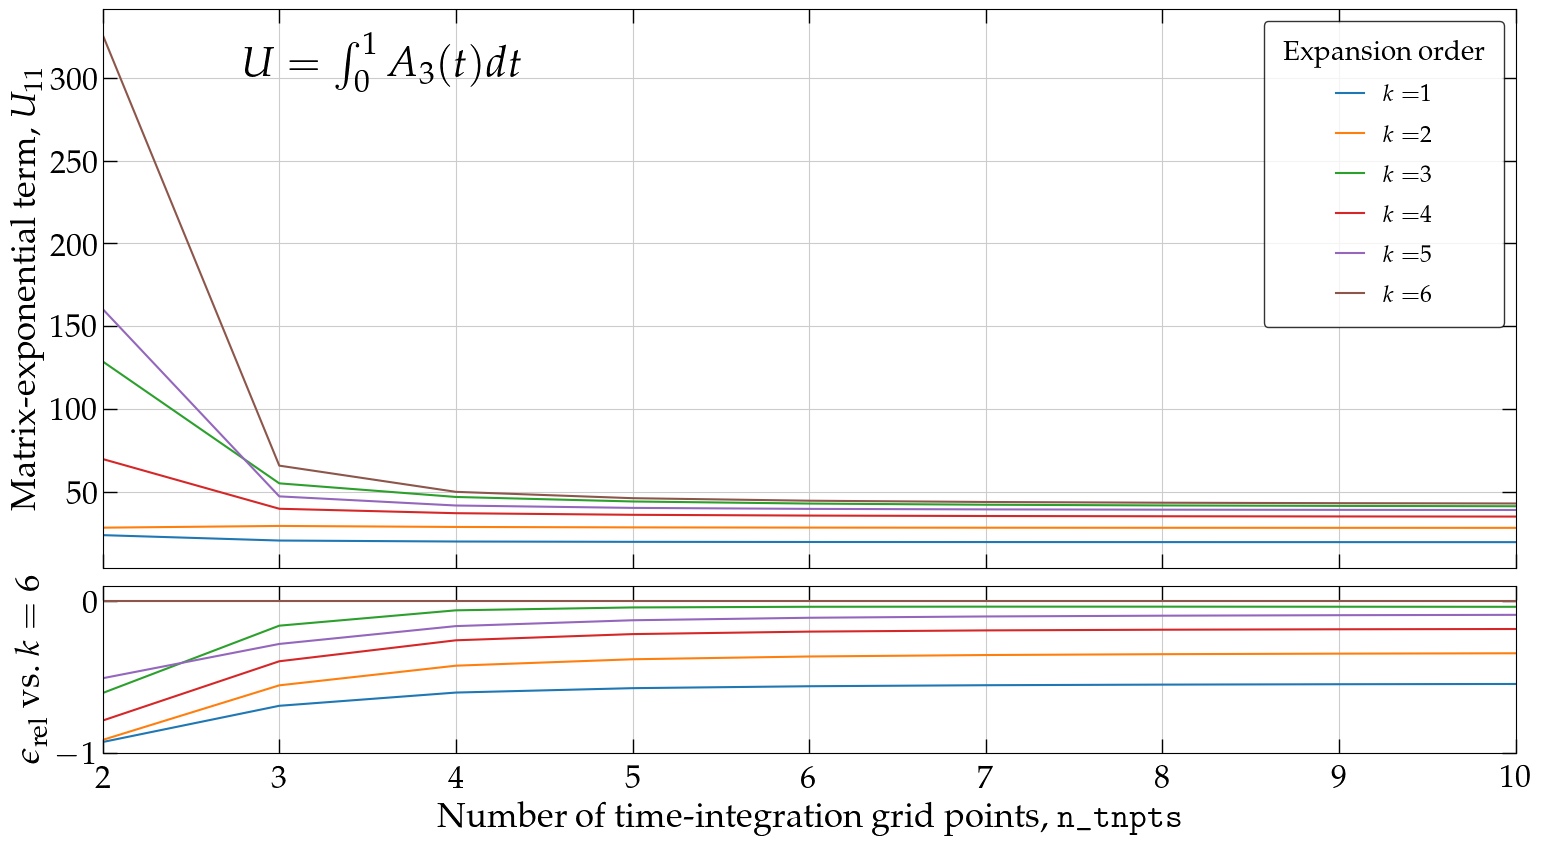

In [88]:
# Open the figure
heights, widths = [1.0, 0.3], [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Plot data
n_tpts = range(n_tpts_min, n_tpts_max+1)
for order in range(order_max):
    ax[0].plot(n_tpts, exp_Omega_elem_sel[order], label='$k = $'+str(order+1))
    rel_error = (exp_Omega_elem_sel[order]-exp_Omega_elem_sel[order_max-1])/exp_Omega_elem_sel[order_max-1]
    ax[1].plot(n_tpts, rel_error)

# Legend
ax[0].legend(fontsize=17, frameon=True, loc='upper right', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Expansion order')

# Annotate
ax[0].annotate(r'$U = \int_0^1 A_3(t) dt$', xy = (0.10, 0.88),  xycoords='axes fraction',  ha='left', fontsize=30)

# Format plot
for i, axx in enumerate(ax):
    axx.set_xlim(n_tpts_min, n_tpts_max)
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='major', axis='y')
ax[1].set_ylim(-1, 0.1)
ax[0].xaxis.set_ticklabels([])
ax[0].set_ylabel(r'Matrix-exponential term, $U_{11}$')
ax[1].set_xlabel(r'Number of time-integration grid points, \texttt{n_tnpts}')
ax[1].set_ylabel(r'$\epsilon_{\rm rel}$ vs.~$k=6$')

# Save plot
# filename = 'magnus_expansion_performance'
# plt.savefig('../fig/'+filename+'.pdf', transparent=False, bbox_inches='tight', dpi=300)
# plt.savefig('../fig/'+filename+'.jpg', transparent=False, bbox_inches='tight', dpi=200)

This shows that, at least for short time intervals, like $t_i = 0$ to $t_f = 1$, it is enough to sue `n_tnpts = 10` points in the integration grid, and expansion up to $k = 6$.

However, because the Magnus expansion involves calculating exponential, it can result in an overflow if its argument is too large, i.e., if $t_f - t_f \gg 1$.  In this case, we partition the interval $[t_i, t_f]$ into multiple, smaller subintervals, compute the matrix exponential in each via Magnus expansion, and then compute their time-ordered product.  (This is actually the strategy adopted by Mag$\nu$s to compute neutrino oscillation probabilities.)